In [3]:
from zipfile import ZipFile
dataset = r"C:\Users\simpl\Downloads\archive.zip"
with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [5]:
with_mask_files=os.listdir('data/with_mask')
print(with_mask_files[0:5])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']


In [6]:
without_mask_files=os.listdir('data/without_mask')
print(without_mask_files[0:5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']


In [7]:
len(with_mask_files)

3725

In [8]:
len(without_mask_files)

3828

Create Labels

With Mask = 1

Without Mask=0

In [9]:
with_mask_label=[1]*3725
without_mask_label=[0]*3828

In [10]:
len(with_mask_label)

3725

In [11]:
len(without_mask_label)

3828

In [12]:
labels=with_mask_label+without_mask_label

In [13]:
len(labels)

7553

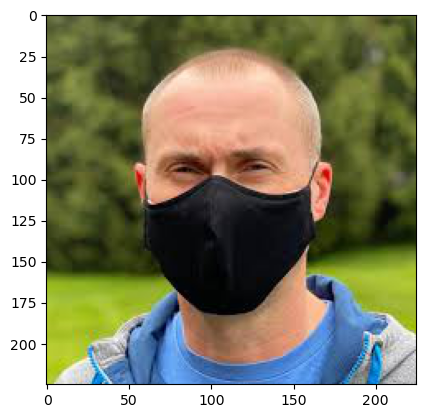

In [14]:
#Displaying mask image

img=mpimg.imread('data/with_mask/with_mask_2538.jpg')
imgplot=plt.imshow(img)
plt.show()

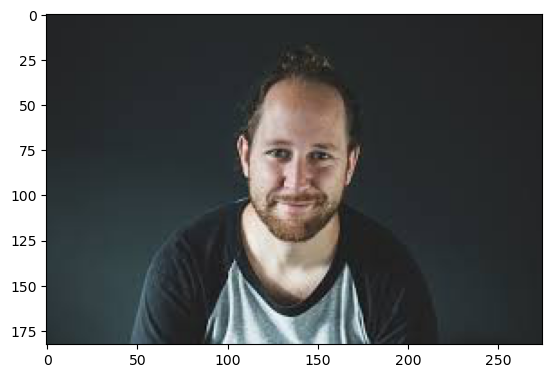

In [15]:
#Displaying without mask image

img=mpimg.imread('data/without_mask/without_mask_2538.jpg')
imgplot=plt.imshow(img)
plt.show()

In [16]:
with_mask_path='data/with_mask/'
data=[]

for img_file in with_mask_files:
    image=Image.open(with_mask_path + img_file)
    image=image.resize((128,128))
    image=image.convert('RGB')
    image=np.array(image)
    data.append(image)

without_mask_path='data/without_mask/'

for img_file in without_mask_files:
    image=Image.open(without_mask_path + img_file)
    image=image.resize((128,128))
    image=image.convert('RGB')
    image=np.array(image)
    data.append(image)

print("Done")

C:\Users\simpl\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Done


In [20]:
len(data)

7553

In [21]:
type(data)

list

In [22]:
data[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], dtype=uint8)

In [23]:
type(data[0])

numpy.ndarray

In [24]:
data[0].shape

(128, 128, 3)

In [25]:
X=np.array(data)
Y=np.array(labels)

In [26]:
X.shape

(7553, 128, 128, 3)

In [27]:
Y.shape

(7553,)

In [28]:
Y

array([1, 1, 1, ..., 0, 0, 0])

In [29]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [30]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [31]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [32]:
X_train[[0]]

array([[[[225, 235, 198],
         [210, 216, 186],
         [189, 188, 169],
         ...,
         [187, 182, 165],
         [181, 174, 151],
         [165, 182, 133]],

        [[224, 228, 217],
         [202, 204, 195],
         [201, 199, 193],
         ...,
         [198, 190, 180],
         [177, 169, 154],
         [158, 182, 141]],

        [[205, 204, 214],
         [221, 219, 227],
         [195, 191, 197],
         ...,
         [183, 173, 174],
         [174, 165, 160],
         [174, 203, 166]],

        ...,

        [[155, 176, 199],
         [160, 180, 197],
         [165, 185, 195],
         ...,
         [ 88,  99,  71],
         [106, 113,  85],
         [ 99, 104,  63]],

        [[150, 177, 197],
         [168, 190, 208],
         [174, 192, 209],
         ...,
         [106, 113,  81],
         [ 99, 103,  67],
         [ 99,  99,  33]],

        [[160, 193, 210],
         [177, 198, 221],
         [175, 189, 214],
         ...,
         [103, 107,  70],
        

In [33]:
X_train_scaled[0]

array([[[0.88235294, 0.92156863, 0.77647059],
        [0.82352941, 0.84705882, 0.72941176],
        [0.74117647, 0.7372549 , 0.6627451 ],
        ...,
        [0.73333333, 0.71372549, 0.64705882],
        [0.70980392, 0.68235294, 0.59215686],
        [0.64705882, 0.71372549, 0.52156863]],

       [[0.87843137, 0.89411765, 0.85098039],
        [0.79215686, 0.8       , 0.76470588],
        [0.78823529, 0.78039216, 0.75686275],
        ...,
        [0.77647059, 0.74509804, 0.70588235],
        [0.69411765, 0.6627451 , 0.60392157],
        [0.61960784, 0.71372549, 0.55294118]],

       [[0.80392157, 0.8       , 0.83921569],
        [0.86666667, 0.85882353, 0.89019608],
        [0.76470588, 0.74901961, 0.77254902],
        ...,
        [0.71764706, 0.67843137, 0.68235294],
        [0.68235294, 0.64705882, 0.62745098],
        [0.68235294, 0.79607843, 0.65098039]],

       ...,

       [[0.60784314, 0.69019608, 0.78039216],
        [0.62745098, 0.70588235, 0.77254902],
        [0.64705882, 0

Building CNN

In [34]:
import tensorflow as tf
from tensorflow import keras

In [48]:
model = keras.Sequential()

# Input layer
model.add(keras.layers.Input(shape=(128,128,3)))

# Data augmentation layer
model.add(data_augmentation)

# CNN layers
model.add(keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Conv2D(128, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(2, activation='softmax'))

In [49]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_face_mask_model.keras",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [51]:
history = model.fit(
    X_train_scaled,
    Y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.7843 - loss: 1.6048
Epoch 1: finished saving model to best_face_mask_model.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 42s 227ms/step - acc: 0.8348 - loss: 0.6856 - val_acc: 0.5190 - val_loss: 1.0438
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - acc: 0.8633 - loss: 0.3167
Epoch 2: finished saving model to best_face_mask_model.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 38s 226ms/step - acc: 0.8786 - loss: 0.3006 - val_acc: 0.5901 - val_loss: 0.8351
Epoch 3/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - acc: 0.8755 - loss: 0.3010
Epoch 3: finished saving model to best_face_mask_model.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 38s 223ms/step - acc: 0.8823 - loss: 0.2886 - val_acc: 0.8959 - val_loss: 0.2398
Epoch 4/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - acc: 0.8800 - loss: 0.2841
Epoch 4: finished saving model to best_face_mask_model.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 37s 220ms/step - acc: 0.8869 - loss: 0.2834 - val_acc: 0.9124 - v

In [52]:
loss,accuracy=model.evaluate(X_test_scaled,Y_test)
print('Test accuracy = ',accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.9159 - loss: 0.1882
Test accuracy =  0.9159497022628784


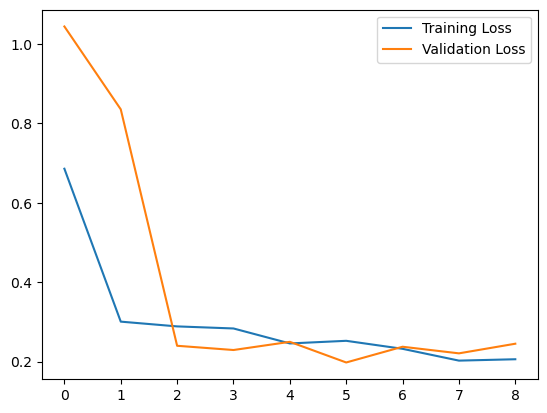

In [53]:
h=history
plt.plot(h.history['loss'],label='Training Loss')
plt.plot(h.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

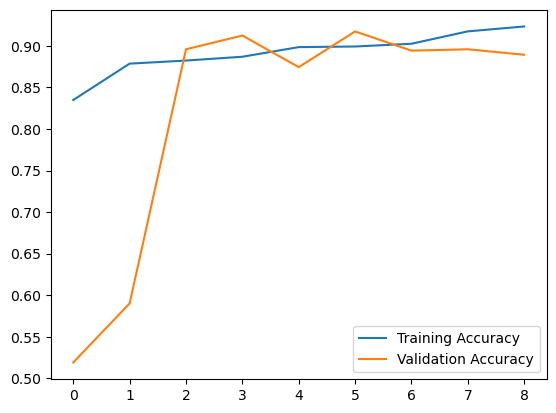

In [54]:
plt.plot(h.history['acc'],label='Training Accuracy')
plt.plot(h.history['val_acc'],label='Validation Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[0.09579252 0.9042075 ]]
1
The person in the image is wearing a mask.


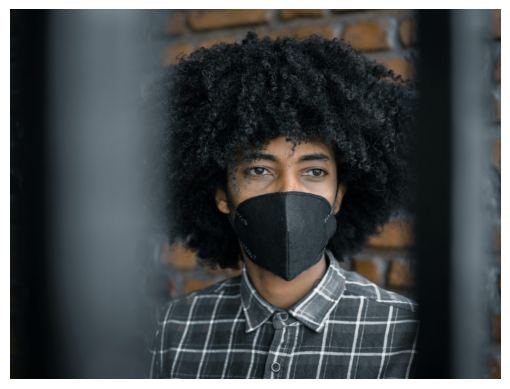

In [55]:
input_image_path = r"C:\Users\simpl\Downloads\tester.jpeg"
input_image = cv2.imread(input_image_path)
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
plt.imshow(input_image)
plt.axis('off')
input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])
input_prediction = model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)
if input_pred_label == 1:
  print('The person in the image is wearing a mask.')
else:
  print('The person in the image in not wearing a mask')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.26137924 0.7386208 ]]
1
The person in the image is wearing a mask.


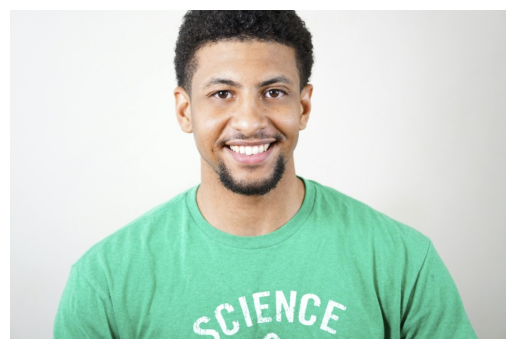

In [56]:
input_image_path = r"C:\Users\simpl\Downloads\tester1.jpeg"
input_image = cv2.imread(input_image_path)
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
plt.imshow(input_image)
plt.axis('off')
input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])
input_prediction = model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)
if input_pred_label == 1:
  print('The person in the image is wearing a mask.')
else:
  print('The person in the image in not wearing a mask')


Integrating Webcam for Real Time face mask detection

In [57]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from IPython.display import display,clear_output
from PIL import Image

In [58]:
model = load_model('best_face_mask_model.keras')

In [59]:
face_cascade=cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

In [62]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam")
    exit()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    # Flip frame for mirror effect
    frame = cv2.flip(frame, 1)

    # Convert to grayscale for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=7,
        minSize=(80, 80)
    )

    for (x, y, w, h) in faces:

        # Extract face region
        face = frame[y:y+h, x:x+w]

        # Convert BGR to RGB
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

        # Resize to match model input size
        face = cv2.resize(face, (128, 128))

        # Normalize
        face = face.astype("float32") / 255.0

        # Add batch dimension
        face = np.expand_dims(face, axis=0)

        # Predict
        prediction = model.predict(face, verbose=0)[0]

        no_mask_prob = prediction[0]
        mask_prob = prediction[1]

        # Choose class with highest probability
        if mask_prob > no_mask_prob:
            label = f"Mask ({mask_prob:.2f})"
            color = (0, 255, 0)
        else:
            label = f"No Mask ({no_mask_prob:.2f})"
            color = (0, 0, 255)

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

        # Draw label
        cv2.putText(
            frame,
            label,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )

    # Show frame
    cv2.imshow("Face Mask Detection", frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()